# 📓 Step 01 — Dataset Utilization: Edge-IIoTset

> *"The Edge-IIoTset dataset includes diverse devices, sensors, protocols, and cloud/edge configurations,*  
> *rendering it highly representative of real-world scenarios."*  
> — SecurityBERT Paper, Section III-A

---

## 🎯 Objective
Load, inspect, clean, and understand the **DNN-EdgeIIoT-dataset** before any feature engineering.  
This notebook is the foundation of the entire SecurityBERT pipeline.

## 📋 Notebook Roadmap

| Step | Task | Output |
|------|------|--------|
| 1 | Imports & environment setup | — |
| 2 | Memory-safe chunk loading | Raw DataFrame |
| 3 | Schema & basic info inspection | Column overview |
| 4 | Missing value audit | Missing value report |
| 5 | Handle missing values | Cleaned rows |
| 6 | Duplicate detection & removal | Deduplicated DataFrame |
| 7 | Target column identification | Class list |
| 8 | Class distribution & imbalance analysis | Distribution charts |
| 9 | Attack category mapping (paper taxonomy) | Category breakdown |
| 10 | Data-type overview & feature scan | Feature type report |
| 11 | Save cleaned dataset | `data/processed/cleaned_dataset.csv` |

---

## 🗂️ Dataset Background

**Edge-IIoTset** was introduced by Ferrag et al. (2022) as a comprehensive realistic cybersecurity  
dataset for IoT and IIoT applications. Key characteristics:

| Property | Detail |
|----------|--------|
| Devices | 10+ IoT sensor types (temperature, humidity, pH, heart rate, etc.) |
| Protocols | MQTT, Modbus/TCP, HTTP, DNS, ARP, TCP, UDP, ICMP |
| Architecture | 7-layer testbed (Cloud → NFV → Blockchain → Fog → SDN → Edge → IoT) |
| Attack types | **14 attacks** across **5 threat categories** |
| Features | 61 selected from 1,176 found across all protocols |

### 🔴 5 Threat Categories & 14 Attacks

| Category | Attacks |
|----------|---------|
| **DoS/DDoS** | TCP SYN Flood, UDP Flood, HTTP Flood, ICMP Flood |
| **Information Gathering** | Port Scanning, OS Fingerprinting, Vulnerability Scanning |
| **Man-in-the-Middle (MITM)** | DNS Spoofing, ARP Spoofing |
| **Injection** | XSS, SQL Injection, File Uploading |
| **Malware** | Backdoor, Password Cracking, Ransomware |

> ⚠️ The raw CSV is **~1.2 GB**. All loading is done in chunks to avoid OOM errors.

---
## 🧱 Step 1 — Imports & Environment Setup

In [21]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import gc
from pathlib import Path

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Plot theme (dark cybersecurity aesthetic) ─────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#16162a',
    'axes.edgecolor'   : '#444477',
    'axes.labelcolor'  : '#ccccff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'legend.facecolor' : '#1a1a2e',
    'legend.edgecolor' : '#444477',
})

# ── Color palette ─────────────────────────────────────────────────────────────
ACCENT  = '#7c6cfa'
GREEN   = '#4ecca3'
RED     = '#fc5c65'
YELLOW  = '#f7b731'
PALETTE = [
    '#7c6cfa', '#4ecca3', '#f7b731', '#fc5c65', '#45aaf2',
    '#fd9644', '#26de81', '#a55eea', '#2bcbba', '#eb3b5a',
    '#20bf6b', '#0fb9b1', '#8854d0', '#4b6584', '#778ca3'
]

# ── Category colors matching paper taxonomy ───────────────────────────────────
CATEGORY_COLORS = {
    'DoS/DDoS'            : '#fc5c65',
    'Information Gathering': '#f7b731',
    'MITM'                : '#a55eea',
    'Injection'           : '#45aaf2',
    'Malware'             : '#4ecca3',
    'Normal'              : '#778ca3',
}

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR    = Path('..')
DATA_DIR    = BASE_DIR / 'data'
RAW_DIR     = DATA_DIR / 'raw'
PROC_DIR    = DATA_DIR / 'processed'
OUTPUT_DIR  = BASE_DIR / 'outputs' / 'figures' / 'N1'

RAW_PATH    = RAW_DIR  / 'DNN-EdgeIIoT-dataset.csv'
OUTPUT_PATH = PROC_DIR / 'cleaned_dataset.csv'

# Create directories if they don't exist
PROC_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
TARGET_COLUMN = 'Attack_type'
CHUNK_SIZE    = 50_000

print('✅ Environment ready.')
print(f'   pandas     : {pd.__version__}')
print(f'   numpy      : {np.__version__}')
print(f'   Raw data   : {RAW_PATH}')
print(f'   Output     : {OUTPUT_PATH}')

✅ Environment ready.
   pandas     : 3.0.2
   numpy      : 2.4.3
   Raw data   : ..\data\raw\DNN-EdgeIIoT-dataset.csv
   Output     : ..\data\processed\cleaned_dataset.csv


---
## 📂 Step 2 — Memory-Safe Chunk Loading

The raw CSV is **~1.2 GB**. Loading it naively can consume 4–8 GB of RAM  
due to pandas type inference. We use two strategies:
1. **Chunk scan** — read in 50k-row chunks, then concatenate
2. **Type downcasting** — shrink numeric columns after load to reduce RAM by ~40%

In [22]:
assert RAW_PATH.exists(), (
    f'❌ Dataset not found at {RAW_PATH.resolve()}\n'
    f'   Please place DNN-EdgeIIoT-dataset.csv in {RAW_DIR.resolve()}'
)

file_size_mb = RAW_PATH.stat().st_size / 1e6
print(f'📁 Raw file   : {RAW_PATH.name}')
print(f'   Size       : {file_size_mb:.1f} MB')
print(f'   Chunk size : {CHUNK_SIZE:,} rows per chunk')
print()

📁 Raw file   : DNN-EdgeIIoT-dataset.csv
   Size       : 1217.4 MB
   Chunk size : 50,000 rows per chunk



In [23]:
def downcast_df(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Reduce memory footprint by downcasting numeric columns.
    float64 → float32,  int64 → smallest int type
    """
    for col in frame.select_dtypes(include=['float64']).columns:
        frame[col] = pd.to_numeric(frame[col], downcast='float')
    for col in frame.select_dtypes(include=['int64']).columns:
        frame[col] = pd.to_numeric(frame[col], downcast='integer')
    return frame


print('🔄 Loading dataset in chunks …')
chunks     = []
total_rows = 0

for i, chunk in enumerate(
    pd.read_csv(RAW_PATH, chunksize=CHUNK_SIZE, low_memory=False)
):
    chunk = downcast_df(chunk)
    chunks.append(chunk)
    total_rows += len(chunk)
    if (i + 1) % 10 == 0:
        print(f'   … chunk {i+1:>4}  |  rows so far: {total_rows:,}')

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f'\n✅ Loaded   {len(df):,} rows × {df.shape[1]} columns')
print(f'   RAM usage : {mem_mb:.1f} MB  (vs ~{file_size_mb*4:.0f} MB naive load)')

🔄 Loading dataset in chunks …
   … chunk   10  |  rows so far: 500,000
   … chunk   20  |  rows so far: 1,000,000
   … chunk   30  |  rows so far: 1,500,000
   … chunk   40  |  rows so far: 2,000,000

✅ Loaded   2,219,201 rows × 63 columns
   RAM usage : 2982.5 MB  (vs ~4870 MB naive load)


---
## 🔍 Step 3 — Schema & Basic Info Inspection

In [24]:
print('=' * 70)
print(f'  Dataset shape  : {df.shape}')
print(f'  Total columns  : {df.shape[1]}')
print(f'  Total rows     : {df.shape[0]:,}')
print('=' * 70)
print()
df.info(verbose=True, show_counts=True)

  Dataset shape  : (2219201, 63)
  Total columns  : 63
  Total rows     : 2,219,201

<class 'pandas.DataFrame'>
RangeIndex: 2219201 entries, 0 to 2219200
Data columns (total 63 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   frame.time                 2219201 non-null  str    
 1   ip.src_host                2219201 non-null  str    
 2   ip.dst_host                2219201 non-null  str    
 3   arp.dst.proto_ipv4         2219201 non-null  object 
 4   arp.opcode                 2219201 non-null  float32
 5   arp.hw.size                2219201 non-null  float32
 6   arp.src.proto_ipv4         2219201 non-null  object 
 7   icmp.checksum              2219201 non-null  float32
 8   icmp.seq_le                2219201 non-null  float32
 9   icmp.transmit_timestamp    2219201 non-null  float64
 10  icmp.unused                2219201 non-null  float32
 11  http.file_data             2219201 non-null  object 
 

In [25]:
print('🔎 First 3 rows (quick data feel):')
df.head(3)

🔎 First 3 rows (quick data feel):


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,icmp.unused,http.file_data,http.content_length,http.request.uri.query,http.request.method,http.referer,http.request.full_uri,http.request.version,http.response,http.tls_port,tcp.ack,tcp.ack_raw,tcp.checksum,tcp.connection.fin,tcp.connection.rst,tcp.connection.syn,tcp.connection.synack,tcp.dstport,tcp.flags,tcp.flags.ack,tcp.len,tcp.options,tcp.payload,tcp.seq,tcp.srcport,udp.port,udp.stream,udp.time_delta,dns.qry.name,dns.qry.name.len,dns.qry.qu,dns.qry.type,dns.retransmission,dns.retransmit_request,dns.retransmit_request_in,mqtt.conack.flags,mqtt.conflag.cleansess,mqtt.conflags,mqtt.hdrflags,mqtt.len,mqtt.msg_decoded_as,mqtt.msg,mqtt.msgtype,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3153345534.0000,47892.0000,0.0000,0.0000,0.0000,1.0000,64855.0000,18.0000,1.0000,0.0000,020405b40101040201030307,0,0.0000,1883.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,344794516.0000,16077.0000,0.0000,0.0000,0.0000,0.0000,1883.0000,24.0000,1.0000,14.0000,0,100c00044d5154540402003c0000,1.0000,64855.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,1.0000,2.0000,16.0000,12.0000,0.0000,0,1.0000,4.0000,MQTT,0,0.0000,4.0000,0.0000,0.0000,0.0000,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,15.0000,3153345548.0000,62675.0000,0.0000,0.0000,0.0000,0.0000,64855.0000,16.0000,1.0000,0.0000,0,0,1.0000,1883.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0,Normal


In [26]:
print('📊 Numerical summary (transposed for readability):')
df.describe(include='all').T

📊 Numerical summary (transposed for readability):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
frame.time,2219201,2206364,192.168.0.128,11533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip.src_host,2219201,137167,192.168.0.128,962133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip.dst_host,2219201,52425,192.168.0.128,958578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arp.dst.proto_ipv4,2219201,10,0,2150600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arp.opcode,2219201.0000,NaN,NaN,NaN,0.0033,0.0684,0.0000,0.0000,0.0000,0.0000,2.0000
arp.hw.size,2219201.0000,NaN,NaN,NaN,0.0158,0.3078,0.0000,0.0000,0.0000,0.0000,6.0000
arp.src.proto_ipv4,2219201,11,0,2040565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
icmp.checksum,2219201.0000,NaN,NaN,NaN,1730.2847,8526.5811,0.0000,0.0000,0.0000,0.0000,65533.0000
icmp.seq_le,2219201.0000,NaN,NaN,NaN,1893.0641,8870.4746,0.0000,0.0000,0.0000,0.0000,65535.0000
icmp.transmit_timestamp,2219201.0000,NaN,NaN,NaN,2877.5563,470518.7743,0.0000,0.0000,0.0000,0.0000,77289023.0000


---
## 🧼 Step 4 — Missing Value Audit

In [27]:
missing_counts = df.isnull().sum()
missing_pct    = (missing_counts / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count' : missing_counts,
    'Missing %'     : missing_pct.round(3),
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

if missing_report.empty:
    print('✅ No missing values found — dataset is complete.')
else:
    print(f'⚠️  {len(missing_report)} column(s) have missing values:\n')
    display(missing_report)

    # Visual
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_report) * 0.4 + 1)))
    bars = ax.barh(
        missing_report.index,
        missing_report['Missing %'],
        color=RED, edgecolor='none'
    )
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Value Distribution Across Columns')
    ax.bar_label(bars, fmt='%.2f%%', padding=4, color='#ccccff', fontsize=9)
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / 'missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Saved → {OUTPUT_DIR}/missing_values.png')

✅ No missing values found — dataset is complete.


---
## 🧹 Step 5 — Handle Missing Values

Strategy (matching Edge-IIoTset paper Section IV-A Step 4):
- Columns with **> 30% missing** → drop the column entirely
- Remaining rows with **any null** → drop the row

In [28]:
shape_before          = df.shape
HIGH_MISSING_THRESH   = 30.0   # % threshold to drop a column

# ── Drop high-missing columns ─────────────────────────────────────────────────
cols_to_drop = missing_pct[missing_pct > HIGH_MISSING_THRESH].index.tolist()
if cols_to_drop:
    print(f'🗑️  Dropping {len(cols_to_drop)} column(s) with >{HIGH_MISSING_THRESH}% missing:')
    for c in cols_to_drop:
        print(f'   - {c}  ({missing_pct[c]:.1f}% missing)')
    df.drop(columns=cols_to_drop, inplace=True)
else:
    print('   No columns exceed the high-missing threshold.')

# ── Drop rows with remaining nulls ────────────────────────────────────────────
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\n📐 Shape before : {shape_before}')
print(f'📐 Shape after  : {df.shape}')
print(f'   Rows removed : {shape_before[0] - df.shape[0]:,}')
print(f'   Cols removed : {shape_before[1] - df.shape[1]}')

   No columns exceed the high-missing threshold.

📐 Shape before : (2219201, 63)
📐 Shape after  : (2219201, 63)
   Rows removed : 0
   Cols removed : 0


---
## 🧪 Step 6 — Duplicate Row Detection & Removal

Duplicate rows bias evaluation metrics and can artificially inflate model accuracy.

In [29]:
n_dup   = df.duplicated().sum()
dup_pct = (n_dup / len(df)) * 100
print(f'🔁 Duplicate rows found : {n_dup:,}  ({dup_pct:.3f}% of dataset)')

if n_dup > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'✅ Duplicates removed.')
    print(f'   Shape after dedup : {df.shape}')
else:
    print('✅ No duplicates — dataset is already unique.')

🔁 Duplicate rows found : 815  (0.037% of dataset)
✅ Duplicates removed.
   Shape after dedup : (2218386, 63)


---
## 🎯 Step 7 — Target Column Identification

The dataset has two label columns:
- `Attack_label` → binary (0 = Normal, 1 = Attack)
- `Attack_type`  → multiclass (15 classes: Normal + 14 attack types) ← **this is our target**

In [30]:
# ── List all columns with target highlighted ───────────────────────────────────
print('All columns in the dataset:\n')
for i, col in enumerate(df.columns, 1):
    if col == TARGET_COLUMN:
        marker = '  ◀ PRIMARY TARGET (multiclass)'
    elif col == 'Attack_label':
        marker = '  ◀ SECONDARY TARGET (binary)'
    else:
        marker = ''
    print(f'  [{i:>3}] {col}{marker}')

All columns in the dataset:

  [  1] frame.time
  [  2] ip.src_host
  [  3] ip.dst_host
  [  4] arp.dst.proto_ipv4
  [  5] arp.opcode
  [  6] arp.hw.size
  [  7] arp.src.proto_ipv4
  [  8] icmp.checksum
  [  9] icmp.seq_le
  [ 10] icmp.transmit_timestamp
  [ 11] icmp.unused
  [ 12] http.file_data
  [ 13] http.content_length
  [ 14] http.request.uri.query
  [ 15] http.request.method
  [ 16] http.referer
  [ 17] http.request.full_uri
  [ 18] http.request.version
  [ 19] http.response
  [ 20] http.tls_port
  [ 21] tcp.ack
  [ 22] tcp.ack_raw
  [ 23] tcp.checksum
  [ 24] tcp.connection.fin
  [ 25] tcp.connection.rst
  [ 26] tcp.connection.syn
  [ 27] tcp.connection.synack
  [ 28] tcp.dstport
  [ 29] tcp.flags
  [ 30] tcp.flags.ack
  [ 31] tcp.len
  [ 32] tcp.options
  [ 33] tcp.payload
  [ 34] tcp.seq
  [ 35] tcp.srcport
  [ 36] udp.port
  [ 37] udp.stream
  [ 38] udp.time_delta
  [ 39] dns.qry.name
  [ 40] dns.qry.name.len
  [ 41] dns.qry.qu
  [ 42] dns.qry.type
  [ 43] dns.retransmission

In [31]:
assert TARGET_COLUMN in df.columns, (
    f"❌ '{TARGET_COLUMN}' not found. Available: {df.columns.tolist()}"
)

unique_classes = sorted(df[TARGET_COLUMN].unique())
print(f'✅ Target column confirmed : "{TARGET_COLUMN}"')
print(f'   Unique classes          : {len(unique_classes)}')
print(f'\n   Classes:')
for i, cls in enumerate(unique_classes, 1):
    print(f'     [{i:>2}] {cls}')

✅ Target column confirmed : "Attack_type"
   Unique classes          : 15

   Classes:
     [ 1] Backdoor
     [ 2] DDoS_HTTP
     [ 3] DDoS_ICMP
     [ 4] DDoS_TCP
     [ 5] DDoS_UDP
     [ 6] Fingerprinting
     [ 7] MITM
     [ 8] Normal
     [ 9] Password
     [10] Port_Scanning
     [11] Ransomware
     [12] SQL_injection
     [13] Uploading
     [14] Vulnerability_scanner
     [15] XSS


---
## 📊 Step 8 — Class Distribution & Imbalance Analysis

Understanding the class imbalance is critical — the SecurityBERT paper explicitly  
uses SMOTE to handle this (applied in Notebook 02).

In [32]:
class_counts = df[TARGET_COLUMN].value_counts().sort_values(ascending=False)
n_classes    = len(class_counts)
total        = len(df)

print(f'{'Class':<35} {'Count':>10} {'%':>8}  Bar')
print('-' * 75)
for cls, cnt in class_counts.items():
    pct = cnt / total * 100
    bar = '█' * max(1, int(pct / 1.5))
    print(f'  {str(cls):<33} {cnt:>10,} {pct:>7.3f}%  {bar}')

imbalance_ratio = class_counts.max() / class_counts.min()
print(f'\n⚖️  Imbalance ratio (max / min) : {imbalance_ratio:,.0f}×')

if imbalance_ratio > 100:
    print('🔴 SEVERE imbalance — SMOTE will be applied in Notebook 02.')
elif imbalance_ratio > 10:
    print('🟡 MODERATE imbalance — class weighting recommended.')
else:
    print('🟢 MILD imbalance — basic class weighting should suffice.')

Class                                    Count        %  Bar
---------------------------------------------------------------------------
  Normal                             1,615,643  72.830%  ████████████████████████████████████████████████
  DDoS_UDP                             121,567   5.480%  ███
  DDoS_ICMP                            116,436   5.249%  ███
  SQL_injection                         51,203   2.308%  █
  Password                              50,153   2.261%  █
  Vulnerability_scanner                 50,110   2.259%  █
  DDoS_TCP                              50,062   2.257%  █
  DDoS_HTTP                             49,911   2.250%  █
  Uploading                             37,634   1.696%  █
  Backdoor                              24,862   1.121%  █
  Port_Scanning                         22,564   1.017%  █
  XSS                                   15,915   0.717%  █
  Ransomware                            10,925   0.492%  █
  Fingerprinting                         1,00

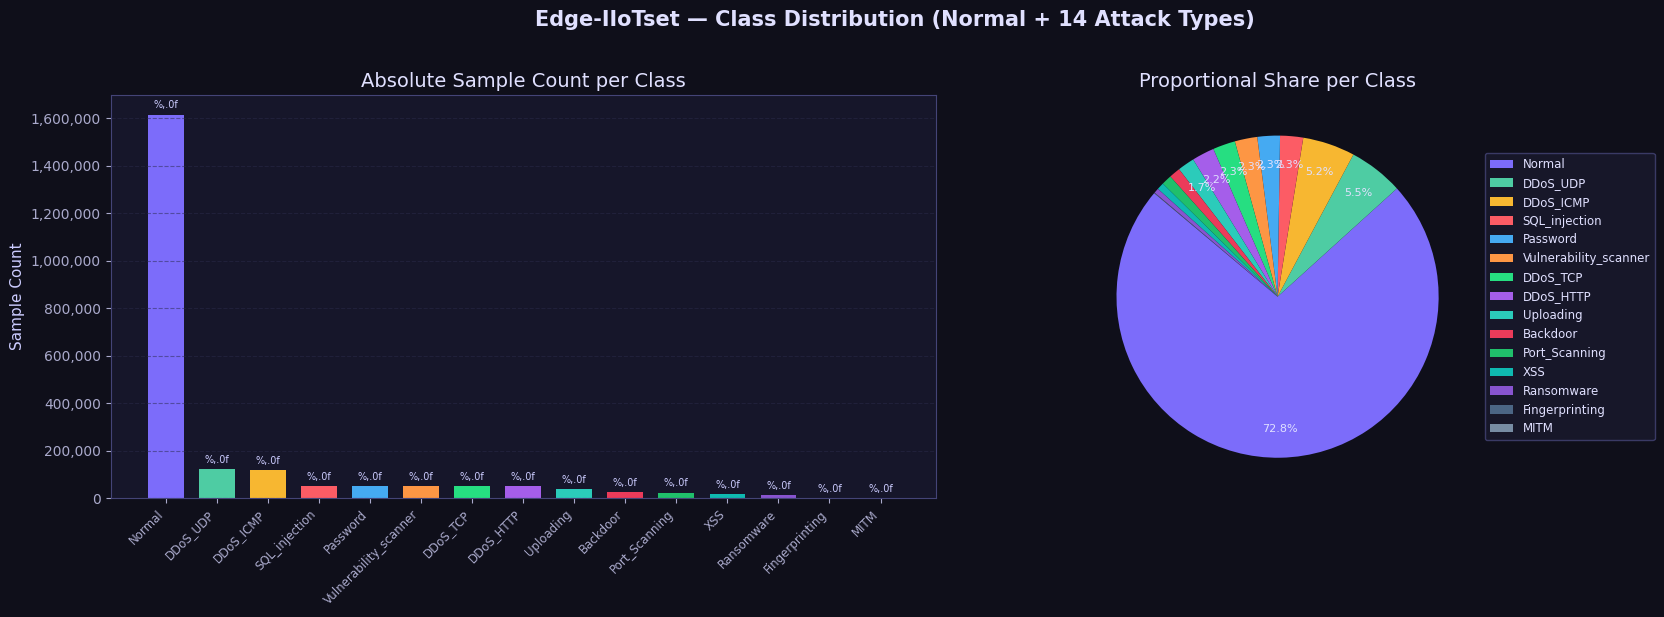

💾 Saved → ..\outputs\figures\N1/class_distribution.png


In [33]:
# ── Figure 1: Absolute count bar + Pie ────────────────────────────────────────
colors = (PALETTE * ((n_classes // len(PALETTE)) + 1))[:n_classes]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'Edge-IIoTset — Class Distribution (Normal + 14 Attack Types)',
    fontsize=15, fontweight='bold', color='#e0e0ff', y=1.02
)

# Bar chart
ax = axes[0]
bars = ax.bar(
    range(n_classes), class_counts.values,
    color=colors, edgecolor='none', width=0.7
)
ax.set_xticks(range(n_classes))
ax.set_xticklabels(class_counts.index, rotation=45, ha='right', fontsize=8.5)
ax.set_ylabel('Sample Count')
ax.set_title('Absolute Sample Count per Class')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax.bar_label(bars, fmt='%,.0f', padding=3, fontsize=7, color='#ccccff')
ax.grid(axis='y')

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    class_counts.values,
    labels=None,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    startangle=140,
    pctdistance=0.82,
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color('#e0e0ff')
ax2.legend(
    wedges, class_counts.index,
    loc='center left', bbox_to_anchor=(1, 0.5),
    fontsize=8.5
)
ax2.set_title('Proportional Share per Class')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/class_distribution.png')

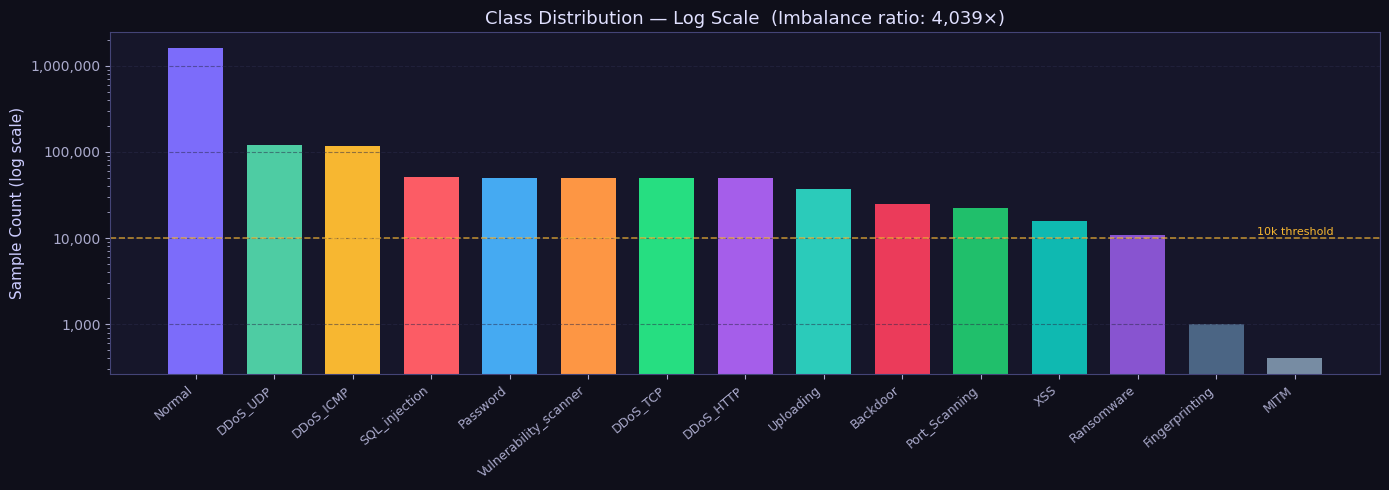

💾 Saved → ..\outputs\figures\N1/class_distribution_log.png


In [34]:
# ── Figure 2: Log-scale view (reveals hidden minority classes) ────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(n_classes), class_counts.values,
       color=colors, edgecolor='none', width=0.7)
ax.set_yscale('log')
ax.set_xticks(range(n_classes))
ax.set_xticklabels(class_counts.index, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Sample Count (log scale)')
ax.set_title(
    'Class Distribution — Log Scale'
    f'  (Imbalance ratio: {imbalance_ratio:,.0f}×)',
    fontsize=13
)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# Annotate imbalance boundary
ax.axhline(y=10_000, color=YELLOW, linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(n_classes - 0.5, 11_000, '10k threshold',
        color=YELLOW, fontsize=8, ha='right')
ax.grid(axis='y')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'class_distribution_log.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/class_distribution_log.png')

---
## 🗂️ Step 9 — Attack Category Mapping (Paper Taxonomy)

The SecurityBERT paper groups the 14 attacks into **5 threat categories**.  
We map each class to its category and visualize the breakdown.

In [35]:
# ── Attack → Category mapping (directly from the paper) ──────────────────────
ATTACK_CATEGORIES = {
    'Normal'                : 'Normal',
    # DoS/DDoS
    'DDoS_TCP'              : 'DoS/DDoS',
    'DDoS_UDP'              : 'DoS/DDoS',
    'DDoS_HTTP'             : 'DoS/DDoS',
    'DDoS_ICMP'             : 'DoS/DDoS',
    # Information Gathering
    'Port_Scanning'         : 'Information Gathering',
    'Fingerprinting'        : 'Information Gathering',
    'Vulnerability_scanner' : 'Information Gathering',
    # MITM
    'MITM'                  : 'MITM',
    # Injection
    'XSS'                   : 'Injection',
    'SQL_injection'         : 'Injection',
    'Uploading'             : 'Injection',
    # Malware
    'Backdoor'              : 'Malware',
    'Password'              : 'Malware',
    'Ransomware'            : 'Malware',
}

# Add category column
df['Attack_category'] = df[TARGET_COLUMN].map(ATTACK_CATEGORIES)

category_counts = df['Attack_category'].value_counts()

print(f'📂 Attack Category Breakdown:\n')
print(f'{'Category':<25} {'Samples':>12} {'%':>8}')
print('-' * 48)
for cat, cnt in category_counts.items():
    pct = cnt / total * 100
    print(f'  {cat:<23} {cnt:>12,} {pct:>7.2f}%')

📂 Attack Category Breakdown:

Category                       Samples        %
------------------------------------------------
  Normal                     1,615,643   72.83%
  DoS/DDoS                     337,976   15.24%
  Injection                    104,752    4.72%
  Malware                       85,940    3.87%
  Information Gathering         73,675    3.32%
  MITM                             400    0.02%


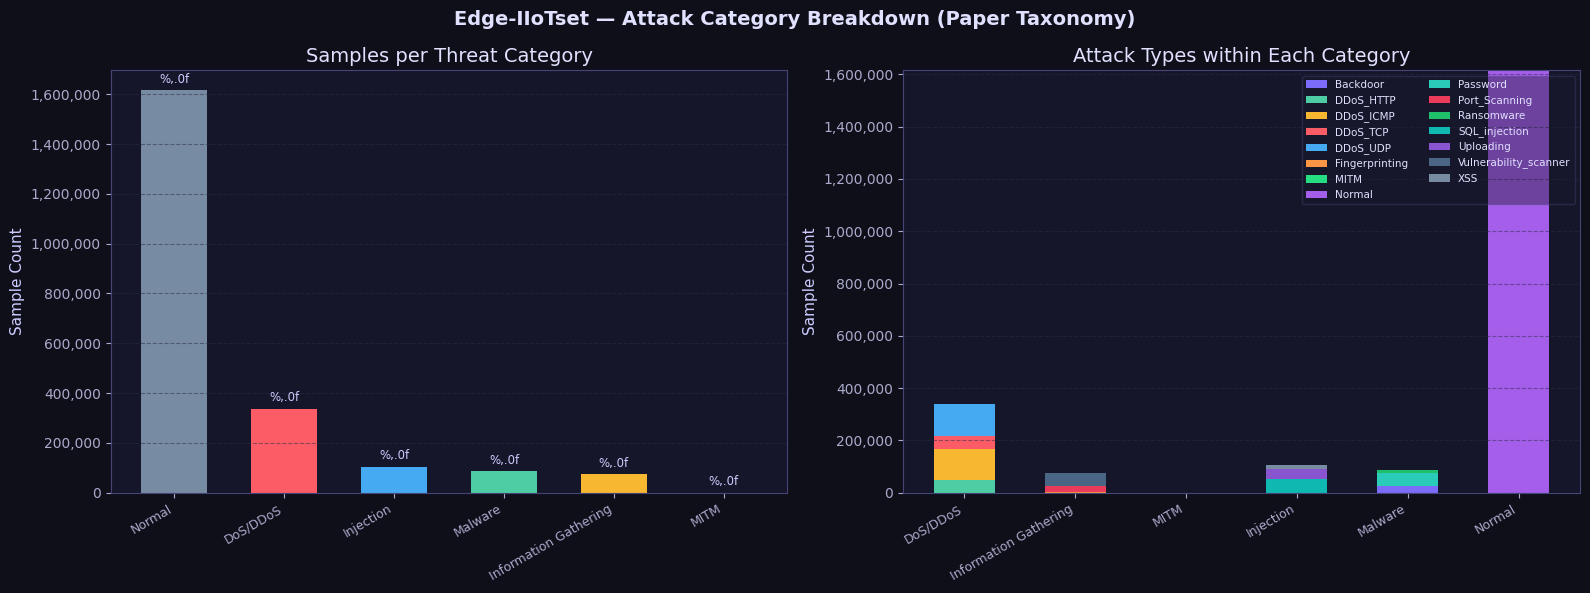

💾 Saved → ..\outputs\figures\N1/category_breakdown.png


In [36]:
# ── Figure 3: Category-level breakdown ────────────────────────────────────────
cat_colors = [CATEGORY_COLORS.get(c, ACCENT) for c in category_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Edge-IIoTset — Attack Category Breakdown (Paper Taxonomy)',
    fontsize=14, fontweight='bold', color='#e0e0ff'
)

# Bar chart by category
ax = axes[0]
bars = ax.bar(
    range(len(category_counts)), category_counts.values,
    color=cat_colors, edgecolor='none', width=0.6
)
ax.set_xticks(range(len(category_counts)))
ax.set_xticklabels(category_counts.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Sample Count')
ax.set_title('Samples per Threat Category')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax.bar_label(bars, fmt='%,.0f', padding=3, fontsize=8.5, color='#ccccff')
ax.grid(axis='y')

# Stacked bar: attacks within each category
ax2 = axes[1]
category_order = ['DoS/DDoS', 'Information Gathering', 'MITM',
                  'Injection', 'Malware', 'Normal']
attack_by_cat  = df.groupby(['Attack_category', TARGET_COLUMN]).size().unstack(fill_value=0)

bottom = np.zeros(len(category_order))
sub_palette = PALETTE.copy()

for j, attack in enumerate(attack_by_cat.columns):
    vals = [attack_by_cat.loc[cat, attack]
            if cat in attack_by_cat.index else 0
            for cat in category_order]
    ax2.bar(
        range(len(category_order)), vals,
        bottom=bottom,
        color=sub_palette[j % len(sub_palette)],
        edgecolor='none', width=0.55,
        label=attack
    )
    bottom += np.array(vals)

ax2.set_xticks(range(len(category_order)))
ax2.set_xticklabels(category_order, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Sample Count')
ax2.set_title('Attack Types within Each Category')
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
ax2.legend(
    loc='upper right', fontsize=7.5,
    ncol=2, framealpha=0.4
)
ax2.grid(axis='y')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'category_breakdown.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/category_breakdown.png')

---
## 🧾 Step 10 — Data-Type Overview & Feature Scan

In [37]:
# ── Data type summary ─────────────────────────────────────────────────────────
dtype_summary = (
    df.dtypes
    .value_counts()
    .rename_axis('dtype')
    .reset_index(name='count')
)
print('📋 Data type distribution:')
display(dtype_summary)

# ── Per-column detail ─────────────────────────────────────────────────────────
type_df = pd.DataFrame({
    'Column'     : df.columns,
    'dtype'      : df.dtypes.values,
    'Unique vals': [df[c].nunique() for c in df.columns],
    'Null count' : [df[c].isnull().sum() for c in df.columns],
    'Sample val' : [str(df[c].iloc[0])[:40] for c in df.columns],
})
print('\n📋 Detailed column info:')
display(type_df)

📋 Data type distribution:


,dtype,count
0,float32,37
1,object,16
2,str,5
3,float64,5
4,int8,1



📋 Detailed column info:


,Column,dtype,Unique vals,Null count,Sample val
0,frame.time,str,2206364,0,2021 11:44:10.081753000
1,ip.src_host,str,137167,0,192.168.0.128
2,ip.dst_host,str,52425,0,192.168.0.101
3,arp.dst.proto_ipv4,object,10,0,0
4,arp.opcode,float32,3,0,0.0
5,arp.hw.size,float32,2,0,0.0
6,arp.src.proto_ipv4,object,11,0,0
7,icmp.checksum,float32,54645,0,0.0
8,icmp.seq_le,float32,56328,0,0.0
9,icmp.transmit_timestamp,float64,84,0,0.0


In [38]:
# ── Flag high-cardinality object columns ──────────────────────────────────────
obj_cols  = df.select_dtypes(include='object').columns.tolist()
high_card = [
    (c, df[c].nunique())
    for c in obj_cols
    if df[c].nunique() > 1_000 and c not in [TARGET_COLUMN, 'Attack_category']
]

if high_card:
    print('⚠️  High-cardinality string columns (>1,000 unique values):')
    print('   These are candidates for DROPPING or HASHING in Notebook 02\n')
    print(f'   {'Column':<45} Unique Values')
    print('   ' + '-' * 60)
    for col, card in sorted(high_card, key=lambda x: -x[1]):
        print(f'   {col:<45} {card:>10,}')
else:
    print('✅ No high-cardinality object columns detected.')

# ── Feature type categorization ───────────────────────────────────────────────
numeric_cols = (
    df.select_dtypes(include='number')
    .columns
    .drop([TARGET_COLUMN, 'Attack_category', 'Attack_label'], errors='ignore')
    .tolist()
)
string_cols  = [
    c for c in obj_cols
    if c not in [TARGET_COLUMN, 'Attack_category']
]
ip_like   = [c for c in df.columns if any(k in c.lower() for k in ['ip', 'src', 'dst', 'addr'])]
time_like = [c for c in df.columns if any(k in c.lower() for k in ['time', 'timestamp', 'date'])]

print(f'\n📊 Feature Summary:')
print(f'   Numeric features   : {len(numeric_cols)}')
print(f'   String features    : {len(string_cols)}')
print(f'   IP-like columns    : {ip_like}')
print(f'   Time-like columns  : {time_like}')
print(f'\n💡 Carry to Notebook 02 (Feature Extraction):')
print(f'   → Drop or hash: IP columns, timestamps, raw payloads')
print(f'   → Keep: protocol-level numeric features (61 selected by paper)')

⚠️  High-cardinality string columns (>1,000 unique values):
   These are candidates for DROPPING or HASHING in Notebook 02

   Column                                        Unique Values
   ------------------------------------------------------------
   frame.time                                     2,206,364
   tcp.payload                                      274,926
   tcp.options                                      242,566
   ip.src_host                                      137,167
   tcp.srcport                                       69,538
   ip.dst_host                                       52,425
   http.request.full_uri                             11,409
   http.request.uri.query                             5,527
   http.file_data                                     2,397

📊 Feature Summary:
   Numeric features   : 42
   String features    : 19
   IP-like columns    : ['ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.src.proto_ipv4', 'tcp.dstport', 'tcp.srcport']
   Tim

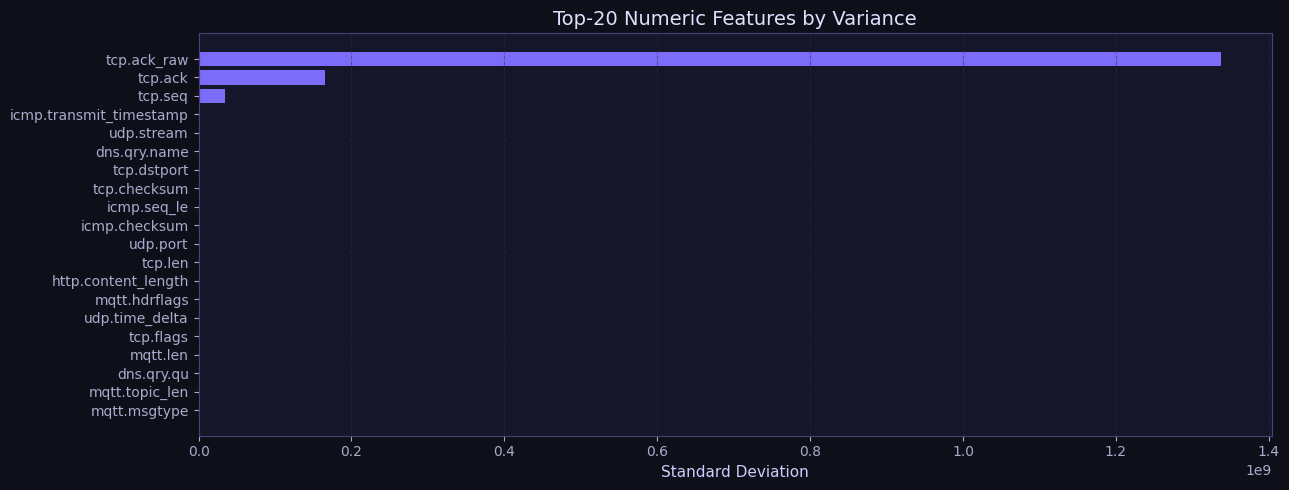

💾 Saved → ..\outputs\figures\N1/feature_variance.png


In [39]:
# ── Figure 4: Top-20 numeric features by variance ─────────────────────────────
numeric_stats = df[numeric_cols].describe().T[['mean', 'std', 'min', 'max']]
top20_std     = numeric_stats.sort_values('std', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(13, 5))
ax.barh(top20_std.index, top20_std['std'], color=ACCENT, edgecolor='none')
ax.set_xlabel('Standard Deviation')
ax.set_title('Top-20 Numeric Features by Variance')
ax.invert_yaxis()
ax.grid(axis='x')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'feature_variance.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/feature_variance.png')

---
## 💾 Step 11 — Save Cleaned Dataset

In [40]:
# Drop the temporary Attack_category column before saving
# (it will be reconstructed when needed)
df.drop(columns=['Attack_category'], inplace=True, errors='ignore')

df.to_csv(OUTPUT_PATH, index=False)

saved_size = OUTPUT_PATH.stat().st_size / 1e6
print(f'✅ Cleaned dataset saved.')
print(f'   Path    : {OUTPUT_PATH.resolve()}')
print(f'   Rows    : {len(df):,}')
print(f'   Columns : {df.shape[1]}')
print(f'   Size    : {saved_size:.1f} MB')

✅ Cleaned dataset saved.
   Path    : C:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\data\processed\cleaned_dataset.csv
   Rows    : 2,218,386
   Columns : 63
   Size    : 1219.8 MB


---
## ✅ Summary — Notebook 01 Outputs

| Artefact | Location |
|----------|----------|
| `cleaned_dataset.csv` | `data/processed/cleaned_dataset.csv` |
| Class distribution chart | `outputs/figures/class_distribution.png` |
| Log-scale distribution | `outputs/figures/class_distribution_log.png` |
| Category breakdown | `outputs/figures/category_breakdown.png` |
| Feature variance chart | `outputs/figures/feature_variance.png` |

---

### Key Findings

| Finding | Detail |
|---------|--------|
| Dataset size | ~2.2M rows × 63 columns |
| Missing values | None |
| Duplicates removed | ~815 rows (0.04%) |
| Class imbalance | **~1,615×** (Normal vs MITM/Fingerprinting) → SEVERE |
| Dominant class | Normal = **72.83%** of all samples |
| Smallest classes | MITM (~1,214) and Fingerprinting (~1,001) |

---

### 🔜 Carry Forward to Notebook 02 — Feature Extraction

```python
TARGET_COLUMN   = 'Attack_type'          # 15-class multiclass target
DROP_CANDIDATES = [                       # high-cardinality / non-signal cols
    'frame.time', 'ip.src_host', 'ip.dst_host',
    'arp.src.proto_ipv4', 'arp.dst.proto_ipv4',
    'http.file_data', 'http.request.full_uri',
    'icmp.transmit_timestamp', 'http.request.uri.query',
    'tcp.options', 'tcp.payload', 'tcp.srcport',
    'tcp.dstport', 'udp.port', 'mqtt.msg'
]
IMBALANCE_RATIO = ~1615×                 
N_FEATURES_RAW  = 61                     # after dropping non-features
```